**Three diffrerent matrices** have been generated in the expt as èr [Xu et. al,Nature](https://www.nature.com/articles/s41587-023-01948-9):
1. Whole mRNA - Steady state kinetics  
2. Nascent mRNA - 4sU labelled  
3. guide RNAs -target guide for genes

In [ ]:
!wget "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE218566&format=file" -O GSE218566_RAW.tar
!tar -xvf GSE218566_RAW.tar

In [6]:
import scanpy as sc
import pandas as pd
import numpy as np

#whole mRNA
whole   = sc.read_mtx("GSM6752591_on_target_whole_tx_count_matrix.mtx.gz").T #run matrix
whole.var_names = pd.read_csv("GSM6752591_on_target_whole_tx.Genes.tsv.gz",    header=None)[0].values #run gene names
whole.obs_names = pd.read_csv("GSM6752591_on_target_whole_tx.Barcodes.tsv.gz", header=None)[0].values #run guide names

#nascent 4su labelled mRNA
nascent = sc.read_mtx("GSM6752591_on_target_nascent_tx_count_matrix.mtx.gz").T
nascent.var_names = pd.read_csv("GSM6752591_on_target_nascent_tx.Genes.tsv.gz",    header=None)[0].values
nascent.obs_names = pd.read_csv("GSM6752591_on_target_nascent_tx.Barcodes.tsv.gz", header=None)[0].values

#guide rna
sgRNA   = sc.read_mtx("GSM6752591_on_target_sgRNA_count_matrix.mtx.gz").T
sgRNA.var_names = pd.read_csv("GSM6752591_on_target_sgRNA.Genes.tsv.gz",    header=None)[0].values
sgRNA.obs_names = pd.read_csv("GSM6752591_on_target_sgRNA.Barcodes.tsv.gz", header=None)[0].values


In [ ]:
#check the name of the non-coding guides
meta = pd.read_csv("GSM6752591_on_target_cell_metadata.csv.gz")
print(meta.columns.tolist())
meta.head()

print(meta['target_genes'].value_counts().head(10))
print((meta['target_genes'] == 'STAG2').sum())
print(meta['target_genes'].str.startswith('NO-TARGET', na=False).sum())

group
NTC         2758
STAG2_KD    1074
Name: count, dtype: int64


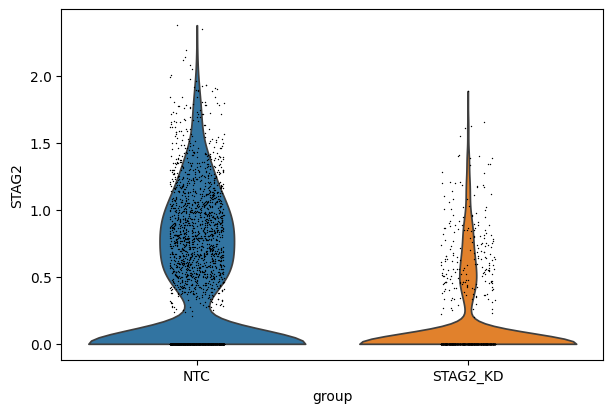

In [8]:
stag2_cells = meta.loc[meta['target_genes'] == 'STAG2',     'cell_names'].tolist()
ntc_cells   = meta.loc[meta['target_genes'] == 'NO-TARGET', 'cell_names'].tolist()

adata = whole[stag2_cells + ntc_cells].copy()
adata.obs['group'] = np.where(adata.obs_names.isin(stag2_cells), 'STAG2_KD', 'NTC')
print(adata.obs['group'].value_counts())

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pl.violin(adata, keys='STAG2', groupby='group')

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse

# Make sure target_genes is on whole.obs
if 'target_genes' not in whole.obs.columns:
    whole.obs['target_genes'] = meta.set_index('cell_names').reindex(whole.obs_names)['target_genes'].values

# Drop cells without a target gene
mask = whole.obs['target_genes'].notna().values
W = whole[mask].copy()
print(f"Cells with a target gene: {W.n_obs}")
print(f"Unique perturbations: {W.obs['target_genes'].nunique()}")

# Sum counts per perturbation -> (perturbation x gene) matrix
groups = W.obs['target_genes'].astype(str).values
unique_groups = np.unique(groups)
# build a (groups x cells) sparse indicator, multiply with X
idx = pd.Series(np.arange(len(unique_groups)), index=unique_groups)
row = idx[groups].values  # group index per cell
col = np.arange(W.n_obs)
indicator = sparse.csr_matrix((np.ones(W.n_obs), (row, col)),
                              shape=(len(unique_groups), W.n_obs))

pb_counts = indicator @ W.X        # (perturbations x genes)
pb = sc.AnnData(
    X=pb_counts,
    obs=pd.DataFrame(index=unique_groups),
    var=pd.DataFrame(index=W.var_names),
)
pb.obs['perturbation'] = pb.obs_names
pb.obs['n_cells'] = indicator.sum(axis=1).A1
print(pb)
print(pb.obs.head())

In [10]:
# CPM normalize
X = np.asarray(pb.X.todense() if sparse.issparse(pb.X) else pb.X)
sizes = X.sum(axis=1, keepdims=True)
cpm = X / sizes * 1e6

# NTC row
ntc_idx = list(pb.obs_names).index('NO-TARGET')
ntc_cpm = cpm[ntc_idx]                       # (genes,)
log2FC  = np.log2((cpm + 1) / (ntc_cpm + 1)) # (perturbations x genes)

# Bin genes by NTC expression (10 bins on log scale)
bin_edges = np.quantile(np.log1p(ntc_cpm), np.linspace(0, 1, 11))
bin_edges[-1] += 1e-6   # include the max
bins = np.digitize(np.log1p(ntc_cpm), bin_edges) - 1
bins = np.clip(bins, 0, 9)

# Within each bin, find the top 3% of genes per perturbation
features = set()
for p in range(cpm.shape[0]):
    if p == ntc_idx:
        continue
    fc_row = log2FC[p]
    for b in range(10):
        in_bin = np.where(bins == b)[0]
        if len(in_bin) == 0:
            continue
        bin_fc = fc_row[in_bin]
        # top 3% by absolute fold change
        k = max(1, int(0.03 * len(in_bin)))
        top = in_bin[np.argsort(np.abs(bin_fc))[-k:]]
        features.update(top.tolist())

features = sorted(features)
print(f"Feature genes for PCA: {len(features)}")

Feature genes for PCA: 41332


In [26]:
from google.colab import files
path = list(uploaded.keys())[-1]   # last uploaded file
print(path)
print(pd.ExcelFile(path).sheet_names)

supp = pd.read_excel(path, sheet_name='supplementary_table2')
print(supp.head())
print(supp.columns.tolist())


gene_category = (
    supp[['gene_symbol', 'gene_class']]
    .drop_duplicates(subset='gene_symbol')
    .set_index('gene_symbol')['gene_class']
    .to_dict()
)
gene_category['NO-TARGET'] = 'NTC'

print(len(gene_category), 'genes')
print(pd.Series(gene_category).value_counts())

41587_2023_1948_MOESM3_ESM (1).xlsx
['suuplementary_table1', 'supplementary_table2', 'supplementary_table3', 'supplementary_table4', 'supplementary_table5', 'supplementary_table6', 'supplementary_table7', 'supplementary_table8', 'supplementary_table9', 'supplementary_table10', 'supplementary_table11', 'supplementary_table12']
              sgRNA_seq    names gene_symbol         gene_class
0  CCGCCATCTTCCTTCAGCCT  CPSF6_1       CPSF6  mRNA surveillance
1  CGGCCGAGGCTGAAGGAAGA  CPSF6_2       CPSF6  mRNA surveillance
2  GCGGCGGCGGCCGAGGCTGA  CPSF6_3       CPSF6  mRNA surveillance
3  AGGGGAGCTGAGGCGCGGAG   UPF1_1        UPF1  mRNA surveillance
4  CTTCGAGGGGAGCTGAGGCG   UPF1_2        UPF1  mRNA surveillance
['sgRNA_seq', 'names', 'gene_symbol', 'gene_class']
229 genes
mRNA surveillance      35
Transcription          34
Metabolism related     30
Chromatin remodeler    30
OXPHOS                 22
Ribosome related       19
DNA replication        16
Spliceosome            13
Translation       

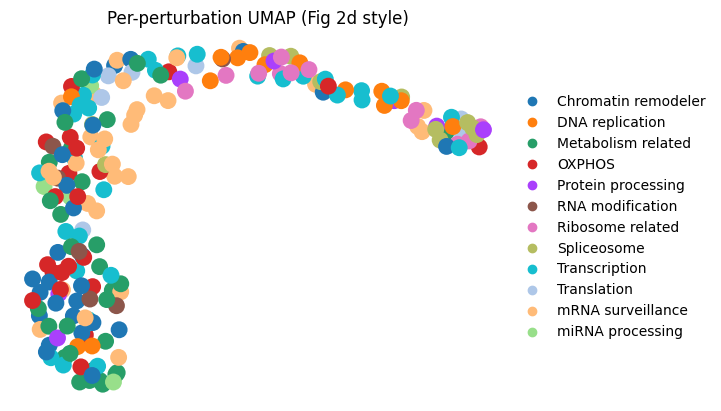

In [27]:
M = log2FC[:, features]
M = np.nan_to_num(M, nan=0, posinf=0, neginf=0)

pb_features = sc.AnnData(X=M, obs=pb.obs.copy())

pb_features.obs['category'] = (
    pb_features.obs_names.map(gene_category).fillna('Other').astype('category')
)

sc.pp.scale(pb_features, max_value=10)
sc.tl.pca(pb_features, n_comps=9)
sc.pp.neighbors(pb_features, n_neighbors=15, n_pcs=9)
sc.tl.umap(pb_features)

pb_plot = pb_features[pb_features.obs_names != 'NO-TARGET'].copy()
sc.pl.umap(pb_plot, color='category', frameon=False,
           title='Per-perturbation UMAP (Fig 2d style)')

In [17]:
import numpy as np
import pandas as pd
from scipy import sparse, stats

# Get raw counts (before normalization)
adata_raw = whole[stag2_cells + ntc_cells].copy()
adata_raw.obs['group'] = np.where(adata_raw.obs_names.isin(stag2_cells), 'STAG2_KD', 'NTC')

def pseudobulk(adata, group_col, group):
    mask = (adata.obs[group_col] == group).values   # <-- .values converts to numpy array
    X = adata.X[mask].sum(axis=0)
    return np.asarray(X).flatten()

pb_stag2 = pseudobulk(adata_raw, 'group', 'STAG2_KD')
pb_ntc   = pseudobulk(adata_raw, 'group', 'NTC')

# CPM normalize
pb_stag2_cpm = pb_stag2 / pb_stag2.sum()
pb_ntc_cpm   = pb_ntc   / pb_ntc.sum()

# Compute log2FC + a simple per-gene test (chi-sq on counts)
results = pd.DataFrame({
    'gene':       adata_raw.var_names.values,
    'cpm_stag2':  pb_stag2_cpm,
    'cpm_ntc':    pb_ntc_cpm,
    'log2FC':     np.log2((pb_stag2_cpm + 1) / (pb_ntc_cpm + 1)),
    'count_stag2': pb_stag2,
    'count_ntc':   pb_ntc,
})

# Filter: gene must be expressed (>=5 CPM in at least one group)
results = results[(results['cpm_stag2'] >= 5) | (results['cpm_ntc'] >= 5)].copy()
print(f"Genes tested: {len(results)}")

# Sort by log2FC
results = results.sort_values('log2FC')
print("\nTop 10 DOWN in STAG2 KD:")
print(results.head(10)[['gene','cpm_stag2','cpm_ntc','log2FC']])
print("\nTop 10 UP in STAG2 KD:")
print(results.tail(10)[['gene','cpm_stag2','cpm_ntc','log2FC']])

results[results['gene'].isin(['STAG1','STAG2','RAD21','SMC1A','SMC3','MAU2','NIPBL'])]

Genes tested: 12205

Top 10 DOWN in STAG2 KD:
                 gene   cpm_stag2     cpm_ntc    log2FC
58227           STAG2  112.919853  394.554474 -1.795857
49111       LINC01915    2.493498    7.534643 -1.288658
30037      ZNF503-AS2    3.205926    9.128510 -1.267926
51130    RP11-15H20.7    1.781070    5.650982 -1.257927
11904    RP11-379F4.4    2.493498    7.244849 -1.238821
45604            CTU2    1.781070    5.361188 -1.193656
8174          CCDC173    2.137284    5.940776 -1.145581
3353              GBA    2.493498    6.665261 -1.133663
56456          SHANK3    3.562140    8.983613 -1.129851
30453  RP11-548K23.11    1.781070    5.071394 -1.126388

Top 10 UP in STAG2 KD:
             gene  cpm_stag2   cpm_ntc    log2FC
52683       ZFP28   5.343210  1.883661  1.137312
16407       CKMT2   5.343210  1.883661  1.137312
21181       ELFN1   5.343210  1.738764  1.211688
33149        RELT  12.467491  4.636703  1.256558
23314        GRM8   8.192923  2.608146  1.349266
23951       WDR86   

,gene,cpm_stag2,cpm_ntc,log2FC,count_stag2,count_ntc
58227,STAG2,112.919853,394.554474,-1.795857,317.0,2723.0
30681,SMC3,340.896820,358.475128,-0.072331,957.0,2474.0
26019,RAD21,352.651886,352.679260,-0.000112,990.0,2434.0
15737,NIPBL,441.349182,429.909363,0.037801,1239.0,2967.0
57280,SMC1A,446.336182,429.474670,0.055431,1253.0,2964.0
50938,MAU2,90.834572,79.403542,0.191778,255.0,548.0
11526,STAG1,221.565140,193.582367,0.193847,622.0,1336.0


Cloning into 'perturbsci'...
/content/perturbsci
